# TASK 1 — Next Word Prediction

In [135]:
# Cell 1

import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [138]:
# Cell 2

sentences_task1 = [

    # I like ...
    "I like red apples",
    "I like red bananas",
    "I like red mangoes",
    "I like red oranges",
    "I like red grapes",
    "I like fresh apples",
    "I like fresh bananas",
    "I like fresh mangoes",
    "I like fresh oranges",
    "I like fresh grapes",

    # I want ...
    "I want some coffee",
    "I want some tea",
    "I want some juice",
    "I want some water",
    "I want some milk",
    "I want some food",
    "I want some pizza",
    "I want some cake",
    "I want some chocolate",
    "I want some icecream",

    # We like ...
    "We like to play",
    "We like to dance",
    "We like to sing",
    "We like to travel",
    "We like to cook",
    "We like to read",
    "We like to swim",
    "We like to walk",
    "We like to run",
    "We like to paint",

    # She likes ...
    "She likes to dance",
    "She likes to sing",
    "She likes to read",
    "She likes to paint",
    "She likes to cook",
    "She likes to travel",
    "She likes to swim",
    "She likes to shop",
    "She likes to write",
    "She likes to draw",

    # He likes ...
    "He likes to play",
    "He likes to code",
    "He likes to read",
    "He likes to run",
    "He likes to swim",
    "He likes to travel",
    "He likes to cook",
    "He likes to draw",
    "He likes to write",
    "He likes to sing",

    # The cat ...
    "The cat is sleeping",
    "The cat is running",
    "The cat is eating",
    "The cat is playing",
    "The cat is jumping",
    "The cat is walking",
    "The cat is drinking",
    "The cat is hiding",
    "The cat is sitting",
    "The cat is sleeping",

    # The dog ...
    "The dog is sleeping",
    "The dog is running",
    "The dog is eating",
    "The dog is playing",
    "The dog is jumping",
    "The dog is walking",
    "The dog is drinking",
    "The dog is hiding",
    "The dog is sitting",
    "The dog is barking",

    # I study ...
    "I study data science",
    "I study machine learning",
    "I study deep learning",
    "I study computer vision",
    "I study neural networks",
    "I study natural language",
    "I study artificial intelligence",
    "I study data mining",
    "I study statistics",
    "I study programming",

    # Students ...
    "Students learn data science",
    "Students learn machine learning",
    "Students learn deep learning",
    "Students learn Python programming",
    "Students practice data analysis",
    "Students study neural networks",
    "Students study computer vision",
    "Students study statistics",
    "Students practice coding",
    "Students learn artificial intelligence"
]

print("Total Task 1 sentences:", len(sentences_task1))

Total Task 1 sentences: 90


In [140]:
# Cell 3

all_words = []

for sentence in sentences:

    all_words.extend(
        sentence.split()
    )

words = sorted(
    set(all_words)
)

word_to_number = {
    word: i
    for i, word in enumerate(words)
}

number_to_word = {
    i: word
    for word, i in word_to_number.items()
}

print("Vocabulary size:", len(words))

print("\nWord to number:")
print(word_to_number)

Vocabulary size: 30

Word to number:
{'He': 0, 'I': 1, 'She': 2, 'The': 3, 'We': 4, 'apples': 5, 'bananas': 6, 'cat': 7, 'code': 8, 'coffee': 9, 'dance': 10, 'dog': 11, 'eating': 12, 'fresh': 13, 'is': 14, 'juice': 15, 'like': 16, 'likes': 17, 'mangoes': 18, 'play': 19, 'read': 20, 'red': 21, 'run': 22, 'running': 23, 'sing': 24, 'sleeping': 25, 'some': 26, 'tea': 27, 'to': 28, 'want': 29}


In [141]:
# Cell 4

X_2_to_2 = []
y_2_to_2 = []

for sentence in sentences:

    sentence_words = sentence.split()

    if len(sentence_words) >= 4:

        X_2_to_2.append(
            sentence_words[:2]
        )

        y_2_to_2.append(
            sentence_words[2:4]
        )

print("First 5 inputs:")
print(X_2_to_2[:5])

print("\nFirst 5 outputs:")
print(y_2_to_2[:5])

First 5 inputs:
[['I', 'like'], ['I', 'like'], ['I', 'like'], ['I', 'like'], ['I', 'like']]

First 5 outputs:
[['red', 'apples'], ['red', 'bananas'], ['red', 'mangoes'], ['fresh', 'apples'], ['fresh', 'bananas']]


In [142]:
# Cell 5

X_2_to_2 = np.array([
    [
        word_to_number[word]
        for word in row
    ]
    for row in X_2_to_2
])

y_2_to_2 = np.array([
    [
        word_to_number[word]
        for word in row
    ]
    for row in y_2_to_2
])

print("X shape:", X_2_to_2.shape)
print("y shape:", y_2_to_2.shape)

X shape: (24, 2)
y shape: (24, 2)


In [143]:
# Cell 6

X_2_to_2 = X_2_to_2.reshape(
    X_2_to_2.shape[0],
    X_2_to_2.shape[1],
    1
)

print("New X shape:", X_2_to_2.shape)

New X shape: (24, 2, 1)


In [146]:
# Cell 7

from tensorflow.keras.layers import Concatenate

model_2_to_2 = Sequential()

model_2_to_2.add(
    SimpleRNN(
        50,
        activation="relu",
        input_shape=(2, 1),
        return_sequences=True
    )
)

model_2_to_2.add(
    SimpleRNN(
        50,
        activation="relu"
    )
)

model_2_to_2.add(
    Dense(
        len(words),
        activation="softmax"
    )
)

model_2_to_2.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_18 (SimpleRNN)       │ (None, 2, 50)          │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_19 (SimpleRNN)       │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 30)             │         1,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,180 (35.86 KB)

 Trainable params: 9,180 (35.86 KB)

 Non-trainable params: 0 (0.00 B)

In [147]:
# Cell 8

X_3_to_1 = []
y_3_to_1 = []

for sentence in sentences:

    sentence_words = sentence.split()

    for i in range(
        len(sentence_words) - 3
    ):

        X_3_to_1.append(
            sentence_words[i:i + 3]
        )

        y_3_to_1.append(
            sentence_words[i + 3]
        )

print("First 10 inputs:")
print(X_3_to_1[:10])

print("\nFirst 10 outputs:")
print(y_3_to_1[:10])

First 10 inputs:
[['I', 'like', 'red'], ['I', 'like', 'red'], ['I', 'like', 'red'], ['I', 'like', 'fresh'], ['I', 'like', 'fresh'], ['I', 'like', 'fresh'], ['I', 'want', 'some'], ['I', 'want', 'some'], ['I', 'want', 'some'], ['We', 'like', 'to']]

First 10 outputs:
['apples', 'bananas', 'mangoes', 'apples', 'bananas', 'mangoes', 'coffee', 'tea', 'juice', 'play']


In [148]:
# Cell 9

X_3_to_1 = np.array([
    [
        word_to_number[word]
        for word in row
    ]
    for row in X_3_to_1
])

y_3_to_1 = np.array([
    word_to_number[word]
    for word in y_3_to_1
])

X_3_to_1 = X_3_to_1.reshape(
    X_3_to_1.shape[0],
    X_3_to_1.shape[1],
    1
)

print("X shape:", X_3_to_1.shape)
print("y shape:", y_3_to_1.shape)

X shape: (24, 3, 1)
y shape: (24,)


In [149]:
# Cell 10

model_3_to_1 = Sequential()

model_3_to_1.add(
    SimpleRNN(
        50,
        activation="relu",
        input_shape=(3, 1)
    )
)

model_3_to_1.add(
    Dense(
        len(words),
        activation="softmax"
    )
)

model_3_to_1.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_20 (SimpleRNN)       │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 30)             │         1,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,130 (16.13 KB)

 Trainable params: 4,130 (16.13 KB)

 Non-trainable params: 0 (0.00 B)

In [150]:
# Cell 11

model_3_to_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [151]:
# Cell 12

history_3_to_1 = model_3_to_1.fit(
    X_3_to_1,
    y_3_to_1,
    epochs=200,
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step - accuracy: 0.0000e+00 - loss: 9.2543
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0000e+00 - loss: 8.8066
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0000e+00 - loss: 8.3747
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 7.9574
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 7.5585
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0000e+00 - loss: 7.1837
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 6.8342
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0000e+00 - loss: 6.5126
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 6.2224
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.0000e+00 - loss: 5.9592
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.0417 - loss: 5.7227
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━

In [152]:
# Cell 13

def predict_next_word_3_to_1(text):

    input_words = text.split()

    input_numbers = [
        word_to_number[word]
        for word in input_words
    ]

    input_array = np.array(
        input_numbers
    ).reshape(1, 3, 1)

    prediction = model_3_to_1.predict(
        input_array,
        verbose=0
    )

    predicted_id = np.argmax(
        prediction
    )

    return number_to_word[
        predicted_id
    ]


tests = [
    "I like red",
    "I want some",
    "The cat is",
    "The dog is"
]

for text in tests:

    print(
        text,
        "→",
        predict_next_word_3_to_1(text)
    )

I like red → mangoes
I want some → tea
The cat is → running
The dog is → sleeping


TASK 2

In [153]:
# Cell 14

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import (
    Masking,
    RepeatVector,
    TimeDistributed
)

In [163]:
# Cell 15 - Task 2 Dataset

sentences_task2 = [
    "I like red apples",
    "I like fresh apples",
    "I like green apples",
    "I like sweet mangoes",
    "I like fresh mangoes",
    "I like ripe bananas",
    "I like yellow bananas",
    "I like red grapes",
    "I like fresh grapes",
    "I like orange juice",

    "I drink fresh juice",
    "I drink cold water",
    "I drink hot coffee",
    "I drink green tea",
    "I drink fresh milk",
    "I eat red apples",
    "I eat ripe bananas",
    "I eat fresh mangoes",
    "I eat sweet oranges",
    "I eat chocolate cake",

    "I study data science",
    "I study machine learning",
    "I study deep learning",
    "I study computer vision",
    "I study neural networks",
    "I study natural language processing",
    "I study artificial intelligence",
    "I study data mining",
    "I study statistics",
    "I study Python programming",

    "I learn data science",
    "I learn machine learning",
    "I learn deep learning",
    "I learn computer vision",
    "I learn neural networks",
    "I learn natural language processing",
    "I learn artificial intelligence",
    "I learn data analysis",
    "I learn Python programming",
    "I learn SQL programming",

    "I practice data science",
    "I practice machine learning",
    "I practice deep learning",
    "I practice Python programming",
    "I practice data analysis",
    "I practice SQL queries",
    "I practice neural networks",
    "I practice computer vision",
    "I practice natural language processing",
    "I practice programming skills",

    "We like red apples",
    "We like fresh fruits",
    "We like green vegetables",
    "We like sweet mangoes",
    "We like cold drinks",
    "We like hot coffee",
    "We like Indian food",
    "We like healthy meals",
    "We like computer games",
    "We like learning together",

    "We study data science",
    "We study machine learning",
    "We study deep learning",
    "We study artificial intelligence",
    "We study Python programming",
    "We study computer vision",
    "We study natural language processing",
    "We study data analytics",
    "We study neural networks",
    "We study statistics",

    "We practice machine learning",
    "We practice data science",
    "We practice Python programming",
    "We practice data analysis",
    "We practice SQL queries",
    "We practice deep learning",
    "We practice computer vision",
    "We practice neural networks",
    "We practice NLP techniques",
    "We practice programming skills",

    "She likes red apples",
    "She likes fresh mangoes",
    "She likes green tea",
    "She likes hot coffee",
    "She likes classical music",
    "She likes modern art",
    "She likes reading books",
    "She likes learning Python",
    "She likes studying science",
    "She likes solving problems",

    "He likes red apples",
    "He likes fresh mangoes",
    "He likes green tea",
    "He likes hot coffee",
    "He likes playing football",
    "He likes reading books",
    "He likes learning Python",
    "He likes studying science",
    "He likes solving problems",
    "He likes writing programs",

    "The cat is sleeping",
    "The cat is eating food",
    "The cat is drinking milk",
    "The cat is playing outside",
    "The cat is running fast",
    "The cat is jumping high",
    "The cat is walking slowly",
    "The cat is sitting quietly",
    "The cat is hiding inside",
    "The cat is chasing birds",

    "The dog is sleeping",
    "The dog is eating food",
    "The dog is drinking water",
    "The dog is playing outside",
    "The dog is running fast",
    "The dog is jumping high",
    "The dog is walking slowly",
    "The dog is sitting quietly",
    "The dog is hiding inside",
    "The dog is chasing balls",

    "Machine learning helps businesses",
    "Machine learning helps companies",
    "Machine learning helps students",
    "Machine learning improves predictions",
    "Machine learning analyzes large datasets",
    "Deep learning solves complex problems",
    "Deep learning analyzes images",
    "Deep learning understands patterns",
    "Data science helps businesses",
    "Data science supports decision making",
    "Artificial intelligence improves automation",
    "Artificial intelligence solves complex problems",
    "Python programming supports data science",
    "Python programming helps machine learning",
    "Computer vision analyzes images",
    "Natural language processing analyzes text",
    "Neural networks learn complex patterns",
    "Data analytics supports business decisions",
    "Statistics helps understand data",
    "SQL helps analyze databases"
]

print("Total sentences:", len(sentences_task2))

Total sentences: 140


In [164]:
# Cell 16 - Create Input and Output Pairs

X_seq = []
y_seq = []

for sentence in sentences_task2:

    words_in_sentence = sentence.split()

    # Choose different split positions
    # so input and output can have different lengths
    for split_point in range(1, len(words_in_sentence)):

        input_words = words_in_sentence[:split_point]
        output_words = words_in_sentence[split_point:]

        X_seq.append(input_words)
        y_seq.append(output_words)

print("Total training samples:", len(X_seq))

print("\nFirst 15 examples:\n")

for i in range(15):
    print("Input :", " ".join(X_seq[i]))
    print("Output:", " ".join(y_seq[i]))
    print()

Total training samples: 449

First 15 examples:

Input : I
Output: like red apples

Input : I like
Output: red apples

Input : I like red
Output: apples

Input : I
Output: like fresh apples

Input : I like
Output: fresh apples

Input : I like fresh
Output: apples

Input : I
Output: like green apples

Input : I like
Output: green apples

Input : I like green
Output: apples

Input : I
Output: like sweet mangoes

Input : I like
Output: sweet mangoes

Input : I like sweet
Output: mangoes

Input : I
Output: like fresh mangoes

Input : I like
Output: fresh mangoes

Input : I like fresh
Output: mangoes



In [165]:
# Cell 17 - Create Vocabulary

all_words = set()

for sentence in sentences_task2:
    for word in sentence.split():
        all_words.add(word)

# Special tokens
word_to_number = {
    "<PAD>": 0,
    "<END>": 1
}

# Add normal words
for word in sorted(all_words):
    if word not in word_to_number:
        word_to_number[word] = len(word_to_number)

number_to_word = {
    number: word
    for word, number in word_to_number.items()
}

vocab_size = len(word_to_number)

print("Vocabulary size:", vocab_size)
print("First few words:")

for word, number in list(word_to_number.items())[:20]:
    print(word, ":", number)

Vocabulary size: 134
First few words:
<PAD> : 0
<END> : 1
Artificial : 2
Computer : 3
Data : 4
Deep : 5
He : 6
I : 7
Indian : 8
Machine : 9
NLP : 10
Natural : 11
Neural : 12
Python : 13
SQL : 14
She : 15
Statistics : 16
The : 17
We : 18
analysis : 19


In [166]:
# Cell 18 - Encode and Pad Sequences

from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

X_encoded = []
y_encoded = []

for input_words, output_words in zip(X_seq, y_seq):

    # Input
    input_numbers = [
        word_to_number[word]
        for word in input_words
    ]

    # Output
    output_numbers = [
        word_to_number[word]
        for word in output_words
    ]

    # Add END token
    output_numbers.append(word_to_number["<END>"])

    X_encoded.append(input_numbers)
    y_encoded.append(output_numbers)


# Find maximum lengths
max_input_length = max(len(x) for x in X_encoded)
max_output_length = max(len(y) for y in y_encoded)

print("Maximum input length :", max_input_length)
print("Maximum output length:", max_output_length)


# Pad input
X_padded = pad_sequences(
    X_encoded,
    maxlen=max_input_length,
    padding="post",
    value=0
)


# Pad output
y_padded = pad_sequences(
    y_encoded,
    maxlen=max_output_length,
    padding="post",
    value=0
)


# SimpleRNN expects 3D input
X_padded = X_padded.reshape(
    X_padded.shape[0],
    X_padded.shape[1],
    1
)

print("\nX shape:", X_padded.shape)
print("y shape:", y_padded.shape)

Maximum input length : 4
Maximum output length: 5

X shape: (449, 4, 1)
y shape: (449, 5)


In [167]:
# Cell 19 - SimpleRNN Sequence-to-Sequence Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Masking,
    RepeatVector,
    TimeDistributed
)

model_seq2seq = Sequential()

# Encoder
model_seq2seq.add(
    Masking(
        mask_value=0,
        input_shape=(max_input_length, 1)
    )
)

model_seq2seq.add(
    SimpleRNN(
        128,
        activation="tanh"
    )
)

# Repeat encoder representation
model_seq2seq.add(
    RepeatVector(max_output_length)
)

# Decoder
model_seq2seq.add(
    SimpleRNN(
        128,
        activation="tanh",
        return_sequences=True
    )
)

# Predict one word at every output position
model_seq2seq.add(
    TimeDistributed(
        Dense(
            vocab_size,
            activation="softmax"
        )
    )
)

model_seq2seq.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_23 (SimpleRNN)       │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_24 (SimpleRNN)       │ (None, 5, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 5, 134)         │        17,286 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,822 (261.02 KB)

 Trainable params: 66,822 (261.02 KB)

 Non-trainable params: 0 (0.00 B)

In [168]:
# Cell 20 - Compile Model

model_seq2seq.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [169]:
# Cell 21 - Train Model

history = model_seq2seq.fit(
    X_padded,
    y_padded,
    epochs=150,
    batch_size=16,
    verbose=1
)

print("Training complete.")

Epoch 1/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3786 - loss: 3.1190
Epoch 2/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5029 - loss: 2.4157
Epoch 3/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5465 - loss: 2.2086
Epoch 4/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5465 - loss: 2.1139
Epoch 5/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5697 - loss: 2.0020
Epoch 6/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5791 - loss: 1.9132
Epoch 7/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5849 - loss: 1.8575
Epoch 8/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5822 - loss: 1.8236
Epoch 9/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5804 - loss: 1.7962
Epoch 10/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5844 - loss: 1.7596
Epoch 11/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5929 - loss: 1.7124
Epoch 12/150
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy:

In [170]:
# Cell 22 - Prediction Function

def predict_sequence(input_text):

    input_words = input_text.split()

    # Convert input words to numbers
    input_numbers = []

    for word in input_words:

        if word in word_to_number:
            input_numbers.append(
                word_to_number[word]
            )
        else:
            print("Unknown word:", word)
            return ""

    # Padding
    input_padded = pad_sequences(
        [input_numbers],
        maxlen=max_input_length,
        padding="post",
        value=0
    )

    # Reshape
    input_padded = input_padded.reshape(
        1,
        max_input_length,
        1
    )

    # Prediction
    prediction = model_seq2seq.predict(
        input_padded,
        verbose=0
    )

    # Convert predicted IDs to words
    predicted_ids = np.argmax(
        prediction[0],
        axis=-1
    )

    predicted_words = []

    for word_id in predicted_ids:

        if word_id == 0:
            continue

        word = number_to_word.get(
            int(word_id),
            ""
        )

        if word == "<END>":
            break

        if word != "":
            predicted_words.append(word)

    return " ".join(predicted_words)

In [171]:
# Cell 23 - Test Predictions

test_inputs = [
    "I like",
    "I study",
    "I study data",
    "I learn",
    "We like",
    "We study",
    "She likes",
    "He likes",
    "The cat is",
    "The dog is",
    "Machine learning",
    "Deep learning",
    "Data science",
    "Artificial intelligence",
    "Python programming"
]

for text in test_inputs:

    result = predict_sequence(text)

    print("Input :", text)
    print("Output:", result)
    print("-" * 50)

Input : I like
Output: red apples
--------------------------------------------------
Input : I study
Output: data learning
--------------------------------------------------
Input : I study data
Output: science
--------------------------------------------------
Input : I learn
Output: red apples
--------------------------------------------------
Input : We like
Output: red meals
--------------------------------------------------
Input : We study
Output: data learning
--------------------------------------------------
Input : She likes
Output: red apples
--------------------------------------------------
Input : He likes
Output: red apples
--------------------------------------------------
Input : The cat is
Output: playing
--------------------------------------------------
Input : The dog is
Output: hiding inside
--------------------------------------------------
Input : Machine learning
Output: helps large
--------------------------------------------------
Input : Deep learning
Output

# TASK 3 — Identify the Missing Middle Word

In [172]:
# Cell 1 - Task 3 Dataset

task3_sentences = [
    # Machine Learning
    "I like machine learning",
    "I study machine learning",
    "I practice machine learning",
    "I enjoy machine learning",
    "I understand machine learning",
    "I explore machine learning",
    "I apply machine learning",
    "I use machine learning",
    "I teach machine learning",
    "I build machine learning",

    # Deep Learning
    "I study deep learning",
    "I practice deep learning",
    "I enjoy deep learning",
    "I understand deep learning",
    "I explore deep learning",
    "I apply deep learning",
    "I use deep learning",
    "I teach deep learning",
    "I build deep learning",
    "I research deep learning",

    # Data Science
    "I study data science",
    "I practice data science",
    "I enjoy data science",
    "I understand data science",
    "I explore data science",
    "I apply data science",
    "I use data science",
    "I teach data science",
    "I build data science",
    "I learn data science",

    # Python Programming
    "I study Python programming",
    "I practice Python programming",
    "I enjoy Python programming",
    "I understand Python programming",
    "I explore Python programming",
    "I apply Python programming",
    "I use Python programming",
    "I teach Python programming",
    "I learn Python programming",
    "I improve Python programming",

    # Computer Vision
    "I study computer vision",
    "I practice computer vision",
    "I enjoy computer vision",
    "I understand computer vision",
    "I explore computer vision",
    "I apply computer vision",
    "I use computer vision",
    "I teach computer vision",
    "I learn computer vision",
    "I build computer vision",

    # Natural Language Processing
    "I study natural language processing",
    "I practice natural language processing",
    "I enjoy natural language processing",
    "I understand natural language processing",
    "I explore natural language processing",
    "I apply natural language processing",
    "I use natural language processing",
    "I teach natural language processing",
    "I learn natural language processing",
    "I research natural language processing",

    # Neural Networks
    "I study neural networks",
    "I practice neural networks",
    "I understand neural networks",
    "I explore neural networks",
    "I apply neural networks",
    "I use neural networks",
    "I teach neural networks",
    "I learn neural networks",
    "I build neural networks",
    "I train neural networks",

    # Artificial Intelligence
    "I study artificial intelligence",
    "I practice artificial intelligence",
    "I enjoy artificial intelligence",
    "I understand artificial intelligence",
    "I explore artificial intelligence",
    "I apply artificial intelligence",
    "I use artificial intelligence",
    "I teach artificial intelligence",
    "I learn artificial intelligence",
    "I build artificial intelligence",

    # Data Analysis
    "I study data analysis",
    "I practice data analysis",
    "I enjoy data analysis",
    "I understand data analysis",
    "I explore data analysis",
    "I apply data analysis",
    "I use data analysis",
    "I teach data analysis",
    "I learn data analysis",
    "I perform data analysis",

    # SQL Queries
    "I study SQL queries",
    "I practice SQL queries",
    "I write SQL queries",
    "I understand SQL queries",
    "I explore SQL queries",
    "I use SQL queries",
    "I teach SQL queries",
    "I learn SQL queries",
    "I improve SQL queries",
    "I optimize SQL queries",

    # Students
    "Students study machine learning",
    "Students practice deep learning",
    "Students learn data science",
    "Students study Python programming",
    "Students practice computer vision",
    "Students learn neural networks",
    "Students study artificial intelligence",
    "Students practice data analysis",
    "Students learn SQL queries",
    "Students study statistics",

    # We
    "We study machine learning",
    "We practice deep learning",
    "We learn data science",
    "We study Python programming",
    "We explore computer vision",
    "We practice neural networks",
    "We study artificial intelligence",
    "We perform data analysis",
    "We write SQL queries",
    "We learn statistics"
]

print("Total sentences:", len(task3_sentences))

Total sentences: 120


In [174]:
# Cell 2 - Remove Middle Word

X_missing = []
y_full = []

for sentence in task3_sentences:

    words = sentence.split()

    # Find middle word
    middle_index = len(words) // 2

    # Remove middle word
    input_words = (
        words[:middle_index] +
        words[middle_index + 1:]
    )

    # Original sentence
    output_words = words

    X_missing.append(input_words)
    y_full.append(output_words)


print("Total examples:", len(X_missing))

print("\nFirst 15 examples:\n")

for i in range(15):

    print("Input :", " ".join(X_missing[i]))
    print("Output:", " ".join(y_full[i]))
    print()

Total examples: 120

First 15 examples:

Input : I like learning
Output: I like machine learning

Input : I study learning
Output: I study machine learning

Input : I practice learning
Output: I practice machine learning

Input : I enjoy learning
Output: I enjoy machine learning

Input : I understand learning
Output: I understand machine learning

Input : I explore learning
Output: I explore machine learning

Input : I apply learning
Output: I apply machine learning

Input : I use learning
Output: I use machine learning

Input : I teach learning
Output: I teach machine learning

Input : I build learning
Output: I build machine learning

Input : I study learning
Output: I study deep learning

Input : I practice learning
Output: I practice deep learning

Input : I enjoy learning
Output: I enjoy deep learning

Input : I understand learning
Output: I understand deep learning

Input : I explore learning
Output: I explore deep learning



In [175]:
# Cell 3 - Verify Required Example

for i in range(len(X_missing)):

    if X_missing[i] == ["I", "like", "learning"]:

        print("Input :", X_missing[i])
        print("Output:", y_full[i])

Input : ['I', 'like', 'learning']
Output: ['I', 'like', 'machine', 'learning']


In [176]:
# Cell 4 - Create Vocabulary

import numpy as np

all_words = set()

for sentence in task3_sentences:

    for word in sentence.split():
        all_words.add(word)


# Special token
task3_word_to_number = {
    "<PAD>": 0
}

# Add words
for word in sorted(all_words):

    if word not in task3_word_to_number:
        task3_word_to_number[word] = len(task3_word_to_number)


task3_number_to_word = {
    number: word
    for word, number in task3_word_to_number.items()
}

task3_vocab_size = len(task3_word_to_number)

print("Vocabulary size:", task3_vocab_size)

Vocabulary size: 41


In [177]:
# Cell 5 - Encode Sequences

X_encoded = []
y_encoded = []

for input_words, output_words in zip(
    X_missing,
    y_full
):

    input_numbers = [
        task3_word_to_number[word]
        for word in input_words
    ]

    output_numbers = [
        task3_word_to_number[word]
        for word in output_words
    ]

    X_encoded.append(input_numbers)
    y_encoded.append(output_numbers)


print("Example encoded input :", X_encoded[0])
print("Example encoded output:", y_encoded[0])

Example encoded input : [1, 20, 19]
Example encoded output: [1, 20, 21, 19]


In [178]:
# Cell 6 - Padding

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_input_length = max(
    len(x) for x in X_encoded
)

max_output_length = max(
    len(y) for y in y_encoded
)


X_padded = pad_sequences(
    X_encoded,
    maxlen=max_input_length,
    padding="post",
    value=0
)

y_padded = pad_sequences(
    y_encoded,
    maxlen=max_output_length,
    padding="post",
    value=0
)


# SimpleRNN input must be 3D
X_padded = X_padded.reshape(
    X_padded.shape[0],
    X_padded.shape[1],
    1
)


print("X shape:", X_padded.shape)
print("Y shape:", y_padded.shape)

X shape: (120, 4, 1)
Y shape: (120, 5)


In [179]:
# Cell 7 - SimpleRNN Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Dense,
    Masking,
    RepeatVector,
    TimeDistributed
)

model_missing = Sequential()

# Encoder
model_missing.add(
    Masking(
        mask_value=0,
        input_shape=(max_input_length, 1)
    )
)

model_missing.add(
    SimpleRNN(
        128,
        activation="tanh"
    )
)

# Repeat encoded information
model_missing.add(
    RepeatVector(max_output_length)
)

# Decoder
model_missing.add(
    SimpleRNN(
        128,
        activation="tanh",
        return_sequences=True
    )
)

# Predict every output word
model_missing.add(
    TimeDistributed(
        Dense(
            task3_vocab_size,
            activation="softmax"
        )
    )
)

model_missing.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_3 (Masking)             │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_25 (SimpleRNN)       │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_26 (SimpleRNN)       │ (None, 5, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 5, 41)          │         5,289 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,825 (214.16 KB)

 Trainable params: 54,825 (214.16 KB)

 Non-trainable params: 0 (0.00 B)

In [180]:
# Cell 8 - Compile Model

model_missing.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


In [181]:
# Cell 9 - Train Model

history_task3 = model_missing.fit(
    X_padded,
    y_padded,
    epochs=300,
    batch_size=8,
    verbose=1
)

print("Training complete.")

Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2717 - loss: 3.1683    
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4083 - loss: 2.2390 
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4733 - loss: 1.8268 
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4933 - loss: 1.5760 
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5500 - loss: 1.4298 
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5900 - loss: 1.3078 
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5867 - loss: 1.2328 
Epoch 8/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6067 - loss: 1.1596 
Epoch 9/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6017 - loss: 1.1084 
Epoch 10/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6200 - loss: 1.0631 
Epoch 11/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6567 - loss: 1.0103 
Epoch 12/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/st

In [182]:
# Cell 10 - Prediction Function

def reconstruct_sentence(input_text):

    input_words = input_text.split()

    # Convert words to numbers
    input_numbers = []

    for word in input_words:

        if word not in task3_word_to_number:

            print("Unknown word:", word)
            return ""

        input_numbers.append(
            task3_word_to_number[word]
        )


    # Padding
    input_padded = pad_sequences(
        [input_numbers],
        maxlen=max_input_length,
        padding="post",
        value=0
    )


    # Reshape
    input_padded = input_padded.reshape(
        1,
        max_input_length,
        1
    )


    # Predict
    prediction = model_missing.predict(
        input_padded,
        verbose=0
    )


    # Convert IDs to words
    predicted_ids = np.argmax(
        prediction[0],
        axis=-1
    )


    predicted_words = []

    for word_id in predicted_ids:

        if word_id == 0:
            continue

        word = task3_number_to_word.get(
            int(word_id),
            ""
        )

        if word != "":
            predicted_words.append(word)


    return " ".join(predicted_words)

In [183]:
# Cell 11 - Test Missing Middle Word

input_text = "I like learning"

result = reconstruct_sentence(input_text)

print("Input :", input_text)
print("Output:", result)

Input : I like learning
Output: I like machine learning


In [186]:
# Cell 12 - Test Multiple Examples

test_inputs = [
    "I study learning",
    "I practice learning",
    "I enjoy learning",
    "I understand learning",
    "I write queries",
    "I understand queries",
    "I use learning",
    "Students study programming",
    "We study learning"
]

for text in test_inputs:

    result = reconstruct_sentence(text)

    print("Input :", text)
    print("Output:", result)
    print("-" * 50)

Input : I study learning
Output: I study machine learning
--------------------------------------------------
Input : I practice learning
Output: I practice machine learning
--------------------------------------------------
Input : I enjoy learning
Output: I enjoy machine learning
--------------------------------------------------
Input : I understand learning
Output: I understand deep learning
--------------------------------------------------
Input : I write queries
Output: I write SQL queries
--------------------------------------------------
Input : I understand queries
Output: I understand SQL queries
--------------------------------------------------
Input : I use learning
Output: I understand deep learning
--------------------------------------------------
Input : Students study programming
Output: Students study Python programming
--------------------------------------------------
Input : We study learning
Output: We study machine learning
--------------------------------------

# TASK 4 — Vanishing and Exploding Gradient

In [187]:
# Cell 1 - Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [188]:
# Cell 2 - Create Long Sequence Dataset

np.random.seed(42)

sequence_length = 100
samples = 500

X_gradient = np.random.randn(
    samples,
    sequence_length,
    1
).astype(np.float32)

# Target = sum of the sequence
y_gradient = np.sum(
    X_gradient,
    axis=1
).astype(np.float32)

print("X shape:", X_gradient.shape)
print("Y shape:", y_gradient.shape)

X shape: (500, 100, 1)
Y shape: (500, 1)


In [189]:
# Cell 3 - SimpleRNN Model

model_gradient = Sequential()

model_gradient.add(
    SimpleRNN(
        50,
        activation="tanh",
        input_shape=(sequence_length, 1)
    )
)

model_gradient.add(
    Dense(1)
)

model_gradient.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_27 (SimpleRNN)       │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [190]:
# Cell 4 - Compile Model

model_gradient.compile(
    optimizer="sgd",
    loss="mse"
)

print("Model compiled successfully.")

Model compiled successfully.


In [191]:
# Cell 5 - Calculate Gradients

X_batch = tf.convert_to_tensor(
    X_gradient[:32]
)

y_batch = tf.convert_to_tensor(
    y_gradient[:32]
)

with tf.GradientTape() as tape:

    predictions = model_gradient(
        X_batch,
        training=True
    )

    loss = tf.reduce_mean(
        tf.square(
            y_batch - predictions
        )
    )

gradients = tape.gradient(
    loss,
    model_gradient.trainable_variables
)

print("Loss:", float(loss))

print("\nGradient values:")

for variable, gradient in zip(
    model_gradient.trainable_variables,
    gradients
):

    if gradient is not None:

        print(
            variable.name,
            "Mean:",
            float(tf.reduce_mean(tf.abs(gradient))),
            "Max:",
            float(tf.reduce_max(tf.abs(gradient)))
        )

Loss: 102.32415008544922

Gradient values:
kernel Mean: 1.3903754949569702 Max: 4.166276454925537
recurrent_kernel Mean: 0.4239603579044342 Max: 2.708045244216919
bias Mean: 1.6756222248077393 Max: 6.0431318283081055
kernel Mean: 1.357787013053894 Max: 3.7163808345794678
bias Mean: 4.151018142700195 Max: 4.151018142700195


In [192]:
# Cell 6 - Vanishing Gradient Demonstration

time_steps = 50

weight = 0.5

vanishing_values = []

for t in range(time_steps):

    gradient = weight ** t

    vanishing_values.append(
        gradient
    )


print("First gradient:", vanishing_values[0])
print("Last gradient :", vanishing_values[-1])

First gradient: 1.0
Last gradient : 1.7763568394002505e-15


In [193]:
# Cell 7 - Exploding Gradient Demonstration

weight = 1.5

exploding_values = []

for t in range(time_steps):

    gradient = weight ** t

    exploding_values.append(
        gradient
    )


print("First gradient:", exploding_values[0])
print("Last gradient :", exploding_values[-1])

First gradient: 1.0
Last gradient : 425081000.1426997


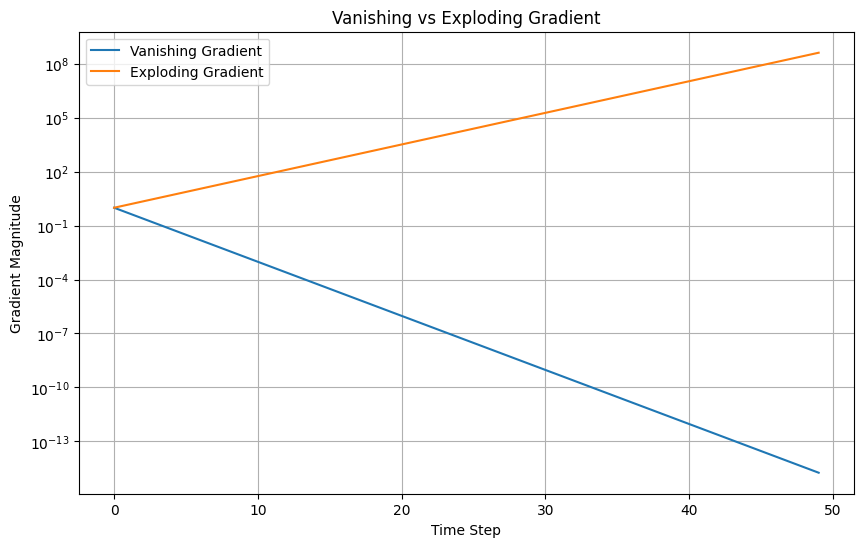

In [194]:
# Cell 8 - Plot Vanishing and Exploding Gradients

time = range(time_steps)

plt.figure(figsize=(10, 6))

plt.plot(
    time,
    vanishing_values,
    label="Vanishing Gradient"
)

plt.plot(
    time,
    exploding_values,
    label="Exploding Gradient"
)

plt.yscale("log")

plt.xlabel("Time Step")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing vs Exploding Gradient")

plt.legend()
plt.grid(True)

plt.show()

In [195]:
# Cell 9 - SimpleRNN Without Gradient Clipping

model_no_clip = Sequential()

model_no_clip.add(
    SimpleRNN(
        50,
        activation="tanh",
        input_shape=(sequence_length, 1)
    )
)

model_no_clip.add(
    Dense(1)
)

model_no_clip.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01
    ),
    loss="mse"
)

print("Model without gradient clipping created.")

Model without gradient clipping created.


In [196]:
# Cell 10 - SimpleRNN With Gradient Clipping

model_clip = Sequential()

model_clip.add(
    SimpleRNN(
        50,
        activation="tanh",
        input_shape=(sequence_length, 1)
    )
)

model_clip.add(
    Dense(1)
)

optimizer_clip = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    clipnorm=1.0
)

model_clip.compile(
    optimizer=optimizer_clip,
    loss="mse"
)

print("Model with gradient clipping created.")

Model with gradient clipping created.


In [197]:
# Cell 11 - Train Without Gradient Clipping

history_no_clip = model_no_clip.fit(
    X_gradient,
    y_gradient,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 111.3214
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 109.6444
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 112.7293
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 112.2377
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 108.5499
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 112.8381
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 112.0884
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 115.5404
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 113.0349
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 108.3904
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 111.0908
Epoch 12/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 113.3735
Epoch 13/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 113.7907
Epoch 14/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 112.5438
Epoch 15/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/s

In [198]:
# Cell 12 - Train With Gradient Clipping

history_clip = model_clip.fit(
    X_gradient,
    y_gradient,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 108.2678
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 105.6980
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 97.7548
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 90.7685
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 84.7584
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 78.8750
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 73.7340
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 72.0836
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 68.1886
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 61.4574
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 64.3347
Epoch 12/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 59.6637
Epoch 13/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 57.1823
Epoch 14/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 60.7325
Epoch 15/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 

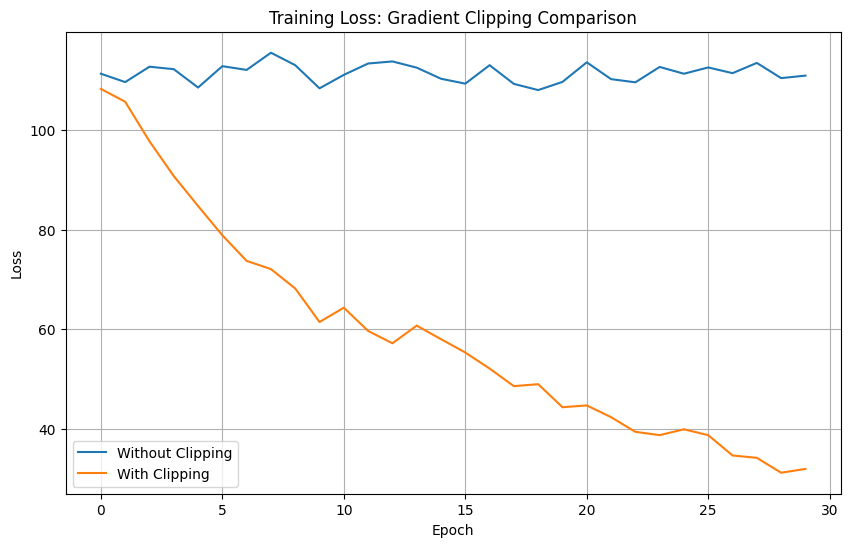

In [199]:
# Cell 13 - Compare Loss

plt.figure(figsize=(10, 6))

plt.plot(
    history_no_clip.history["loss"],
    label="Without Clipping"
)

plt.plot(
    history_clip.history["loss"],
    label="With Clipping"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss: Gradient Clipping Comparison")

plt.legend()
plt.grid(True)

plt.show()